# Class Imbalance Ablation: TF-IDF + Logistic Regression

Compare model performance when trained on the original imbalanced dataset (~20% toxic) vs. a balanced dataset (50/50 undersample). Both models are evaluated on the same imbalanced test set.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path("../../../..").resolve()
DATA_DIR = Path("data")
MODEL_TYPE = "logreg"
DATA_PATH = ROOT / "data/train_dataset_clean.csv"

IMBAL_DIR = DATA_DIR / "imbalanced"
BAL_DIR = DATA_DIR / "balanced"
IMBAL_DIR.mkdir(parents=True, exist_ok=True)
BAL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

## 1. Train & Evaluate (imbalanced)

In [ ]:
if not (IMBAL_DIR / "evaluation_results.json").exists():
    !cd {ROOT} && python3 -m model.train --model {MODEL_TYPE} --data {DATA_PATH} --output {IMBAL_DIR.resolve()}
    !cd {ROOT} && python3 -m model.evaluate --model {MODEL_TYPE} --model-dir {IMBAL_DIR.resolve()}
else:
    print(f"Results already exist in {IMBAL_DIR}, skipping.")

## 2. Train & Evaluate (balanced)

In [ ]:
if not (BAL_DIR / "evaluation_results.json").exists():
    # Create balanced dataset (undersample safe to match toxic count)
    df = pd.read_csv(DATA_PATH)
    toxic = df[df['y'] == 1]
    safe = df[df['y'] == 0].sample(n=len(toxic), random_state=SEED)
    df_bal = pd.concat([toxic, safe]).sample(frac=1, random_state=SEED)
    bal_csv = DATA_DIR / "train_balanced.csv"
    df_bal.to_csv(bal_csv, index=False)
    print(f"Balanced CSV: {len(df_bal)} rows ({df_bal['y'].mean():.0%} toxic)")

    !cd {ROOT} && python3 -m model.train --model {MODEL_TYPE} --data {bal_csv.resolve()} --output {BAL_DIR.resolve()}
    !cd {ROOT} && python3 -m model.evaluate --model {MODEL_TYPE} --model-dir {BAL_DIR.resolve()}
    bal_csv.unlink()
else:
    print(f"Results already exist in {BAL_DIR}, skipping.")

## 3. Load Results

In [4]:
with open(IMBAL_DIR / "evaluation_results.json") as f:
    results_imbal = json.load(f)

with open(BAL_DIR / "evaluation_results.json") as f:
    results_bal = json.load(f)

print("Imbalanced results loaded:", list(results_imbal.keys()))
print("Balanced results loaded:", list(results_bal.keys()))

Imbalanced results loaded: ['quality', 'confusion_matrix', 'latency', 'throughput_samples_per_sec', 'peak_memory_mb', 'quality_tuned', 'best_threshold', 'confusion_matrix_tuned']
Balanced results loaded: ['quality', 'confusion_matrix', 'latency', 'throughput_samples_per_sec', 'peak_memory_mb', 'quality_tuned', 'best_threshold', 'confusion_matrix_tuned']


## 4. Comparison

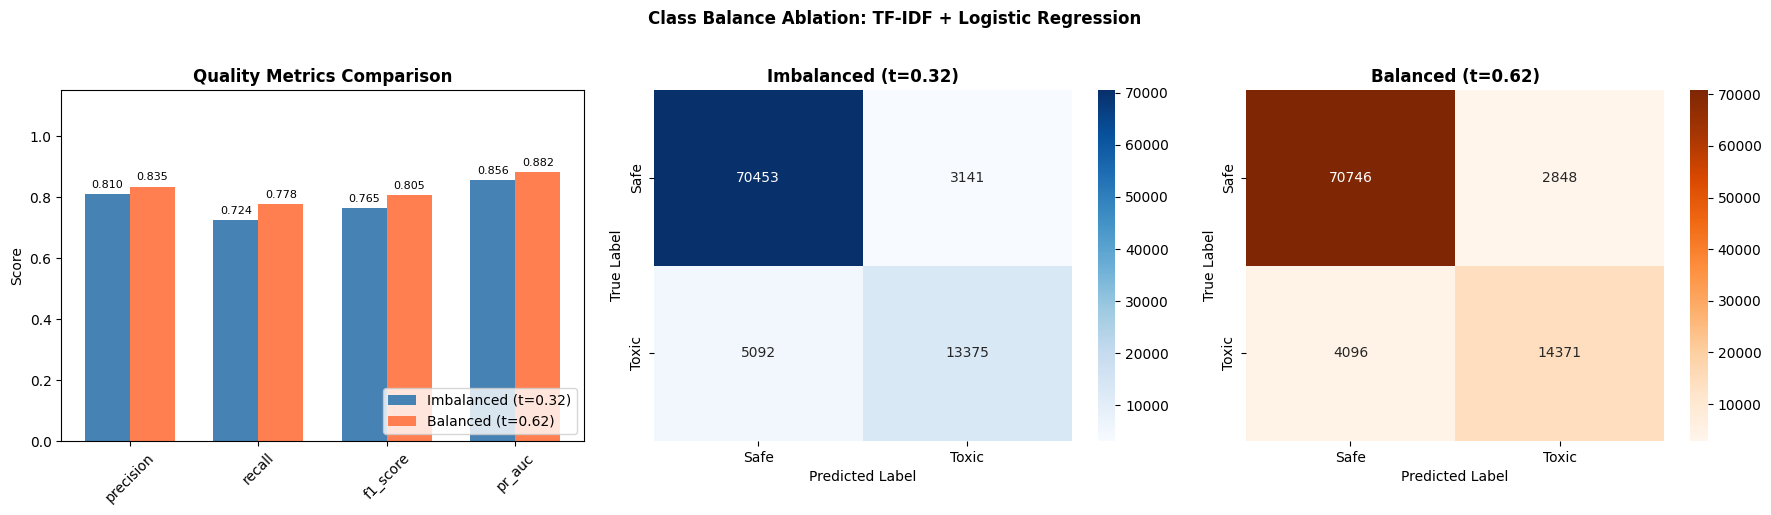


CLASS BALANCE ABLATION SUMMARY (tuned thresholds)
Metric            Imbalanced     Balanced      Delta
--------------------------------------------------
precision             0.8098       0.8346    +0.0248
recall                0.7243       0.7782    +0.0539
f1_score              0.7647       0.8054    +0.0408
pr_auc                0.8560       0.8820    +0.0260
--------------------------------------------------
Threshold               0.32         0.62


In [5]:
metrics_names = ['precision', 'recall', 'f1_score', 'pr_auc']
imbal_vals = [results_imbal['quality_tuned'][m] for m in metrics_names]
bal_vals = [results_bal['quality_tuned'][m] for m in metrics_names]
t_imbal = results_imbal['best_threshold']
t_bal = results_bal['best_threshold']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Grouped bar chart
x = np.arange(len(metrics_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, imbal_vals, width,
                     label=f'Imbalanced (t={t_imbal:.2f})', color='steelblue')
bars2 = axes[0].bar(x + width/2, bal_vals, width,
                     label=f'Balanced (t={t_bal:.2f})', color='coral')
axes[0].set_ylabel('Score')
axes[0].set_title('Quality Metrics Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, rotation=45)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.15)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.3f}',
                 ha='center', fontsize=8)

# 2. Confusion matrix -- imbalanced (tuned)
cm_imbal = np.array(results_imbal['confusion_matrix_tuned'])
sns.heatmap(cm_imbal, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
axes[1].set_title(f'Imbalanced (t={t_imbal:.2f})', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# 3. Confusion matrix -- balanced (tuned)
cm_bal = np.array(results_bal['confusion_matrix_tuned'])
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
axes[2].set_title(f'Balanced (t={t_bal:.2f})', fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.suptitle('Class Balance Ablation: TF-IDF + Logistic Regression', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 70)
print("CLASS BALANCE ABLATION SUMMARY (tuned thresholds)")
print("=" * 70)
print(f"{'Metric':<15} {'Imbalanced':>12} {'Balanced':>12} {'Delta':>10}")
print("-" * 50)
for m in metrics_names:
    iv = results_imbal['quality_tuned'][m]
    bv = results_bal['quality_tuned'][m]
    delta = bv - iv
    print(f"{m:<15} {iv:>12.4f} {bv:>12.4f} {delta:>+10.4f}")
print("-" * 50)
print(f"{'Threshold':<15} {t_imbal:>12.2f} {t_bal:>12.2f}")

## Interpretation

**Experimental setup.** Both models use identical TF-IDF + Logistic Regression architecture and hyperparameters (`C=1.0`, `max_features=10000`, bigrams). The **imbalanced** model trains on the full cleaned dataset (~460k, ~20% toxic); the **balanced** model trains on an undersampled subset (~133k, 50/50). Both are evaluated on the same held-out test set reflecting real-world class distribution (~20% toxic). Each model uses its own threshold tuned on the shared validation set.

**Expected patterns:**

| Effect | Why |
|---|---|
| **Recall increases** with balanced training | The model sees equal toxic/safe examples and is not biased toward the majority class |
| **Precision may decrease** | More aggressive toxic predictions produce more false positives on safe text |
| **F1 trade-off** | Whether F1 improves depends on whether the recall gain outweighs the precision loss; threshold tuning partially compensates |
| **PR-AUC** is threshold-independent | Changes here reflect genuine ranking-quality differences, not threshold effects |

**For a safety filter:** higher recall (catching toxic content) is typically preferred over higher precision, since missing toxic content is more harmful than over-flagging safe content. If balanced training improves recall with an acceptable precision trade-off, it is the better choice.

**Confound:** the balanced model trains on fewer samples (~133k vs ~331k). Observed differences may partly reflect dataset size rather than pure class-balance effects.